In [1]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
from liset_paper import liset_paper as liset_tk

import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns
from utils import *

In [2]:
parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
ripples=[]

In [3]:
def get_dataset_info(liset):
    ripples= liset.ripples_GT
    numsamples=liset.data.shape[0]
    print("Dataset Time:",round(numsamples / liset.fs,2), "seconds")
    time_seconds = numsamples / liset.fs
    minutes= np.floor(time_seconds/ 60)
    extra_seconds = time_seconds%60
    print("Dataset time:", int(minutes), "minutes", round(extra_seconds,2), "seconds")
    
    # Ripple Analysis
    rate = ripples.shape[0] / time_seconds  # Ripples per second
    ripples = ripples[np.argsort(ripples[:, 0])]
    total_ripple_samples= np.sum(ripples[:, 1] - ripples[:, 0])   # Total ripple time in seconds
   
    print("Number of ripples:", ripples.shape[0])
    print("Ripples per minute:", round(ripples.shape[0] / time_seconds*60, 2))
    print("Ripples per second:", round(rate, 2))
    print("Seconds per ripple:", round(time_seconds / ripples.shape[0], 2))
    print("Total Ripple Time:", round(total_ripple_samples/ liset.fs, 2), "seconds")
    print("Percentage of time with ripples:", round(total_ripple_samples / numsamples * 100, 2), "%")


    durations = (ripples[:, 1] - ripples[:, 0])/liset.fs*1000 # Convert to milliseconds
    mean_duration = np.mean(durations)
    std_duration = np.std(durations)
    print(f"Mean Duration: {mean_duration:.2f} ms, Std Duration: {std_duration:.2f} ms, Rate: {rate:.2f} ripples/s")
    distance_between=[ripples[i, 0] - ripples[i-1, 1] for i in range(1, ripples.shape[0])]

def pie_ripples(liset):
    # Pie Chart for Ripples
    ripples= liset.ripples_GT
    total_samples= liset.data.shape[0]
    total_ripple_samples= np.sum(ripples[:, 1] - ripples[:, 0])
    total_non_ripple_samples= total_samples - total_ripple_samples
    labels = ['Ripples', 'Non-Ripples']
    sizes = [total_ripple_samples, total_non_ripple_samples]
    colors = ['#ff9999','#66b3ff']
    explode = (0.1, 0)  # explode the first slice
    plt.figure(figsize=(8, 6))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
            shadow=True, startangle=140)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.title("Ripple vs Non-Ripple Samples")
    plt.show()

def plot_ripple_durations(liset):
    ripples = liset.ripples_GT
    durations = (ripples[:, 1] - ripples[:, 0]) / liset.fs * 1000  # Convert to milliseconds
    mean_duration = np.mean(durations)
    std_duration = np.std(durations)
    median_duration = np.median(durations)
    percentile75_duration = np.percentile(durations, 75)
    percentile25_duration = np.percentile(durations, 25)
    plt.figure(figsize=(10, 6))
    plt.hist(durations, bins=50, color='blue', alpha=0.7)
    plt.axvline(mean_duration, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_duration:.2f} ms')
    plt.axvline(median_duration, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_duration:.2f} ms')
    plt.axvline(percentile75_duration, color='black', linestyle='-', linewidth=0.5, label=f'75th Percentile: {percentile75_duration:.2f} ms')
    plt.axvline(percentile25_duration, color='black', linestyle='-', linewidth=0.5, label=f'25th Percentile: {percentile25_duration:.2f} ms')
    plt.title('Ripple Durations')
    plt.xlabel('Duration (ms)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_ripples_per_second(liset, bg_color="#bacad394", color='blue'):
    ripples = liset.ripples_GT
    fs = liset.fs
    start_times_sec = ripples[:, 0] / fs  # Convert ripple start samples to seconds
   
    # Round down to the nearest second for bucketing
    rounded_starts = np.floor(start_times_sec).astype(int)

    fig, ax = plt.subplots(figsize=(12,1))
    ax.set_facecolor(bg_color)
    
    for t in rounded_starts:
        ax.axvline(x=t, color=color, linewidth=1)

    # ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_yticks([])  # Hide y-axis ticks
    ax.set_xlim(0, np.ceil(liset.data.shape[0] / fs))  # x-axis limits to full duration
    ax.tick_params(axis='x', labelsize=14)

    plt.tight_layout()
    plt.show()

    return fig, ax


Dataset: Amigo2_2019-07-11_11-57-07
Dataset Time: 2398.86 seconds
Dataset time: 39 minutes 58.86 seconds
Number of ripples: 1309
Ripples per minute: 32.74
Ripples per second: 0.55
Seconds per ripple: 1.83
Total Ripple Time: 65.93 seconds
Percentage of time with ripples: 2.75 %
Mean Duration: 50.37 ms, Std Duration: 14.57 ms, Rate: 0.55 ripples/s


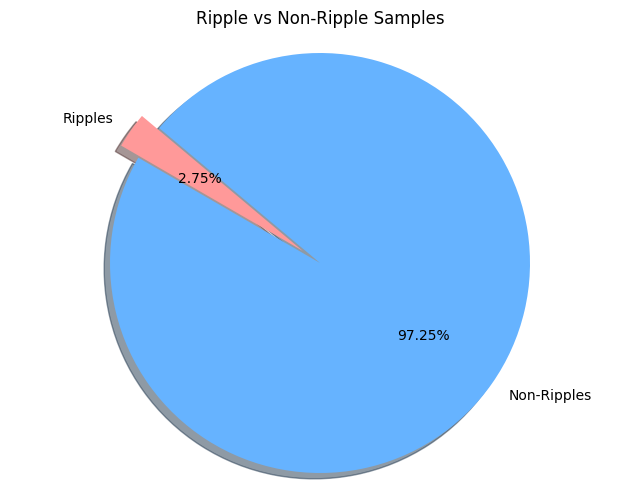

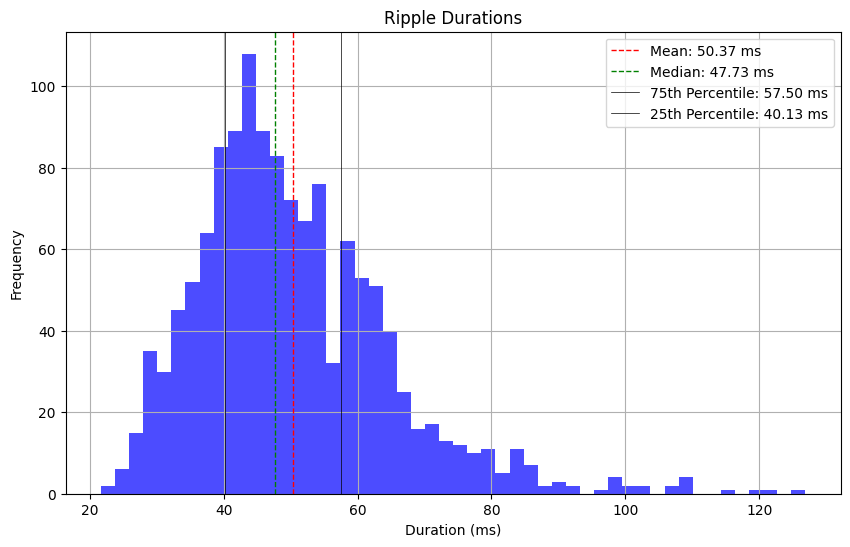

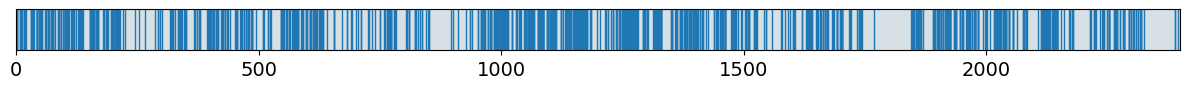

In [4]:
id=0
dataset=datasets[id]
color=colors[id % len(colors)]
print(f"Dataset: {dataset}")
dataset_path=os.path.join(parent,dataset)
liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples.append(liset.ripples_GT)
# print(liset.ripples_GT)
get_dataset_info(liset)
pie_ripples(liset)
plot_ripple_durations(liset)
fig,ax=plot_ripples_per_second(liset,color=color)
fig_path=os.path.join(os.getcwd(),"pngs", f"{dataset}_ripples_per_second.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')


Dataset: Dlx1_2021-02-12_12-46-54
Dataset Time: 1021.34 seconds
Dataset time: 17 minutes 1.34 seconds
Number of ripples: 211
Ripples per minute: 12.4
Ripples per second: 0.21
Seconds per ripple: 4.84
Total Ripple Time: 10.09 seconds
Percentage of time with ripples: 0.99 %
Mean Duration: 47.84 ms, Std Duration: 12.00 ms, Rate: 0.21 ripples/s


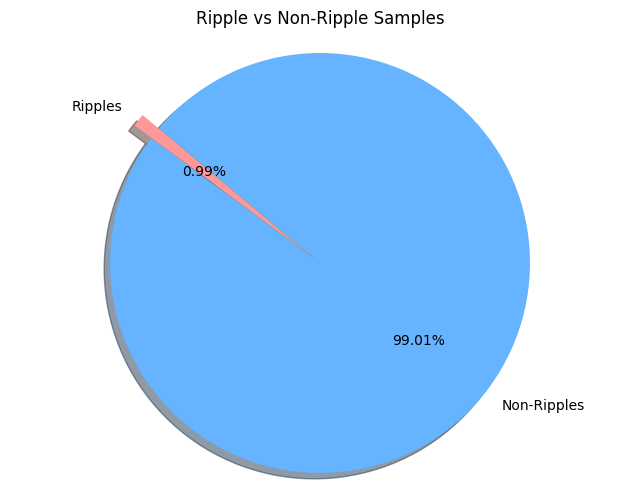

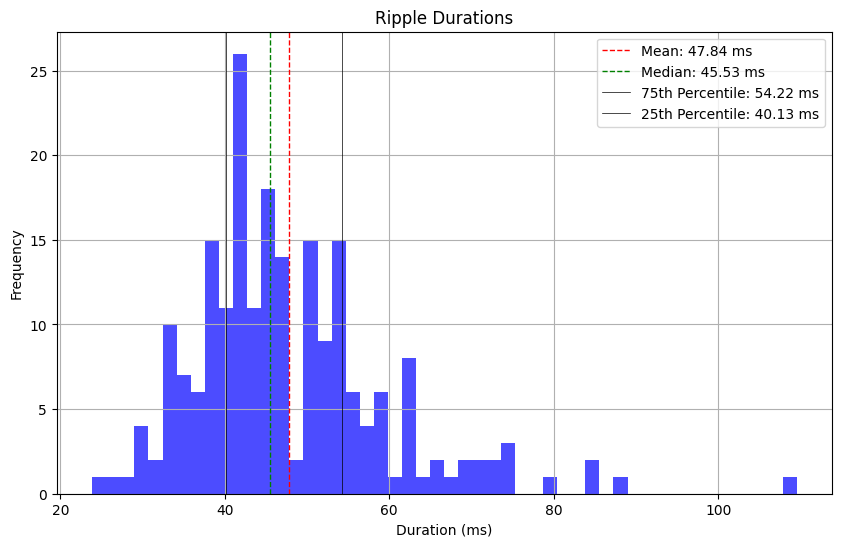

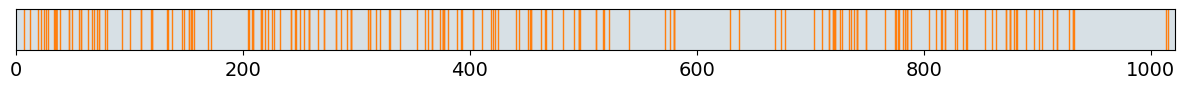

In [5]:
id=1
dataset=datasets[id]
color=colors[id % len(colors)]
print(f"Dataset: {dataset}")
dataset_path=os.path.join(parent,dataset)
liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples.append(liset.ripples_GT)
# print(liset.ripples_GT)
get_dataset_info(liset)
pie_ripples(liset)
plot_ripple_durations(liset)
fig,ax=plot_ripples_per_second(liset,color=color)
fig_path=os.path.join(os.getcwd(),"pngs", f"{dataset}_ripples_per_second.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')

Dataset: Som2_2019-07-24_12-01-49
Dataset Time: 1036.25 seconds
Dataset time: 17 minutes 16.25 seconds
Number of ripples: 485
Ripples per minute: 28.08
Ripples per second: 0.47
Seconds per ripple: 2.14
Total Ripple Time: 17.84 seconds
Percentage of time with ripples: 1.72 %
Mean Duration: 36.78 ms, Std Duration: 10.67 ms, Rate: 0.47 ripples/s


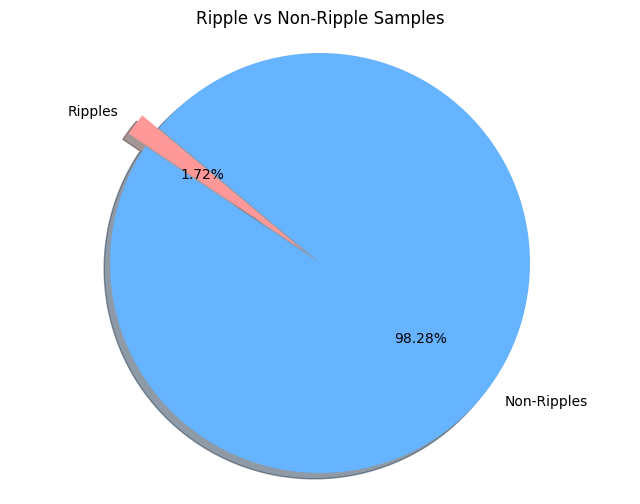

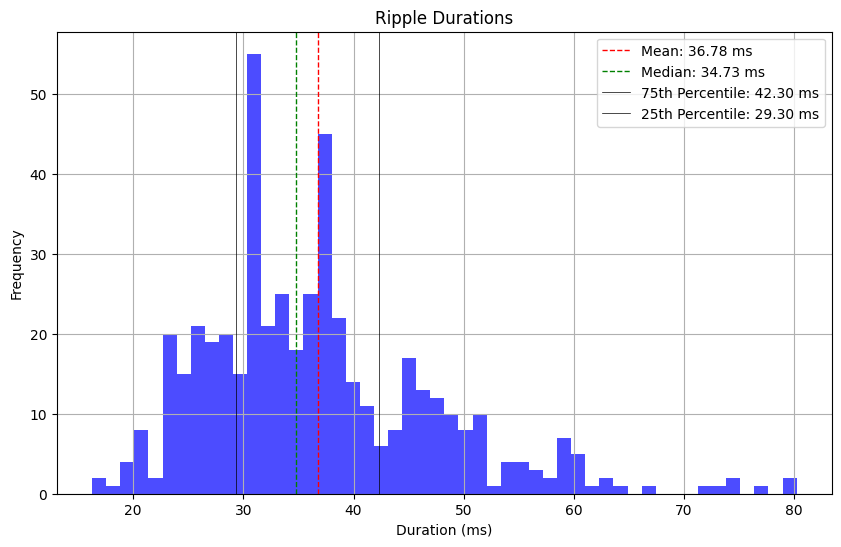

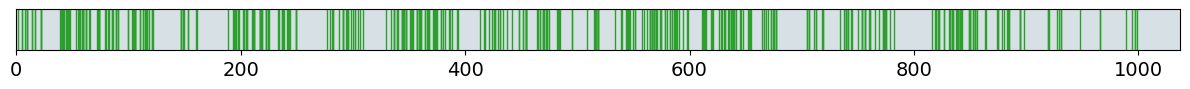

In [6]:
id=2
dataset=datasets[id]
color=colors[id % len(colors)]
print(f"Dataset: {dataset}")
dataset_path=os.path.join(parent,dataset)
liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples.append(liset.ripples_GT)
# print(liset.ripples_GT)
get_dataset_info(liset)
pie_ripples(liset)
plot_ripple_durations(liset)
fig,ax=plot_ripples_per_second(liset,color=color)
fig_path=os.path.join(os.getcwd(),"pngs", f"{dataset}_ripples_per_second.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')

Dataset: Thy7-2020-11-11_16-05-00
Dataset Time: 744.21 seconds
Dataset time: 12 minutes 24.21 seconds
Number of ripples: 1064
Ripples per minute: 85.78
Ripples per second: 1.43
Seconds per ripple: 0.7
Total Ripple Time: 52.59 seconds
Percentage of time with ripples: 7.07 %
Mean Duration: 49.43 ms, Std Duration: 16.39 ms, Rate: 1.43 ripples/s


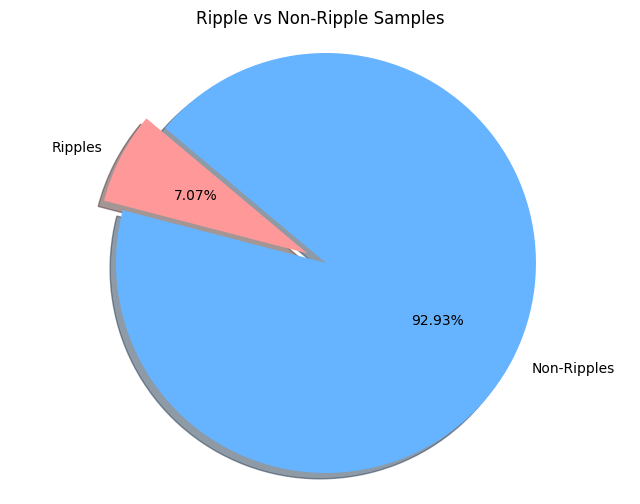

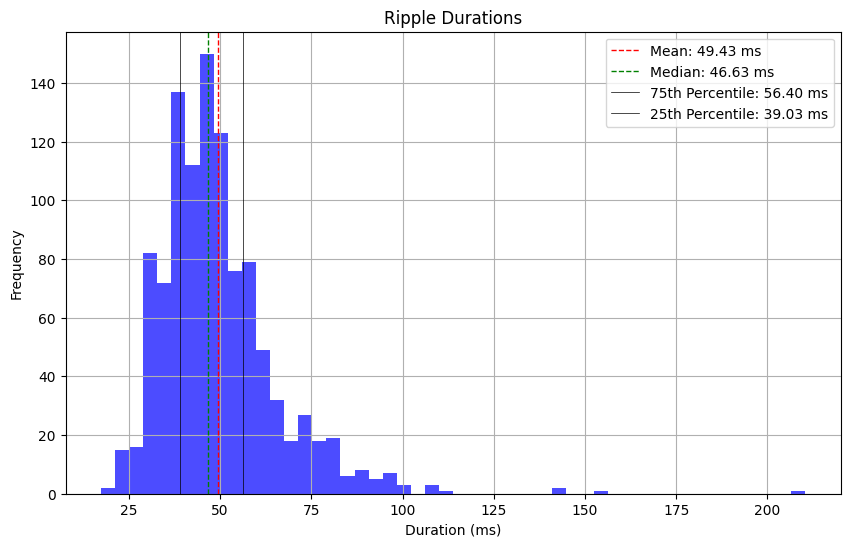

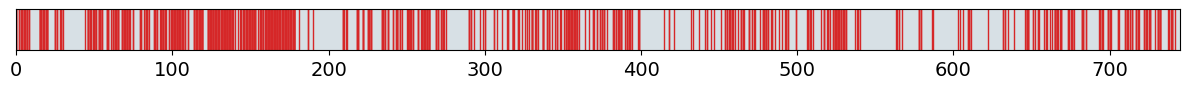

In [7]:
id=3
dataset=datasets[id]
color=colors[id % len(colors)]
print(f"Dataset: {dataset}")
dataset_path=os.path.join(parent,dataset)
liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples.append(liset.ripples_GT)
# print(liset.ripples_GT)
get_dataset_info(liset)
pie_ripples(liset)
plot_ripple_durations(liset)
fig,ax=plot_ripples_per_second(liset,color=color)
fig_path=os.path.join(os.getcwd(),"pngs", f"{dataset}_ripples_per_second.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')

In [ ]:
def plot_multi_ripple_histograms(ripples_list, fs, bins=50, alpha=0.6,colors=colors):
    """
    Plot ripple duration histograms for multiple datasets, each with a unique color.

    Parameters:
    - ripples_list: List of arrays (each [N x 2]) containing ripple start/end samples
    - fs: Sampling frequency in Hz
    - bins: Number of histogram bins
    - alpha: Transparency for histogram bars
    """

    assert len(ripples_list) == 4, "This function expects exactly 4 datasets."

    # colors = ['blue', 'green', 'orange', 'red']
    labels = ['Amigo', 'Dlx', 'Som', 'Thy']
    
    plt.figure(figsize=(10, 6))
    durations= []
    for idx, ripples in enumerate(ripples_list):
        durations_ms = (ripples[:, 1] - ripples[:, 0]) / fs * 1000  # Convert to ms
        durations.extend(durations_ms)
        mean_dur = np.mean(durations_ms)
        median_dur = np.median(durations_ms)
        plt.hist(durations_ms, bins=bins,histtype='step', alpha=alpha, color=colors[idx], label=f'{labels[idx]} (Mean: {mean_dur:.1f} ms, Median: {median_dur:.1f} ms)', edgecolor='black')
        # Mean and Median lines
        # plt.axvline(mean_dur, color=colors[idx], linestyle='--', linewidth=1)
        # plt.axvline(median_dur, color=colors[idx], linestyle=':', linewidth=1)

    mean_dur = np.mean(durations)
    median_dur = np.median(durations)
    plt.hist(durations, bins=bins, alpha=0.1, color="grey", label=f'Total (Mean: {mean_dur:.1f} ms, Median: {median_dur:.1f} ms)', edgecolor='black')
    plt.axvline(mean_dur, color='black', linestyle='--', linewidth=2, )
    plt.axvline(median_dur, color='black', linestyle=':', linewidth=2,)

    plt.xlabel("Ripple Duration (ms)", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Ripple Duration Histogram Across Recording Sessions", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_stacked_histogram(ripples_list, fs, bins=50, colors=None):
    """
    Plots a stacked histogram of ripple durations from multiple datasets.

    Parameters:
        ripples_list (list of np.ndarray): Each array contains ripple events as [start, end] samples.
        fs (float): Sampling frequency in Hz.
        bins (int): Number of histogram bins.
        colors (list of str): List of color strings for each dataset.
    
    Returns:
        fig, ax: Matplotlib figure and axes.
    """
    assert len(ripples_list) == 4, "This function expects exactly 4 datasets."

    # Default colors
    if colors is None:
        colors = ['royalblue', 'seagreen', 'darkorange', 'crimson']
    
    labels = ['Amigo', 'Dlx', 'Som', 'Thy']

    # Convert ripple durations from samples to ms
    durations_list = [
        (r[:, 1] - r[:, 0]) / fs * 1000  # duration in ms
        for r in ripples_list
    ]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot stacked histogram
    ax.hist(
        durations_list, bins=bins, stacked=True,
        color=colors[:len(ripples_list)], label=labels,
        edgecolor='black', linewidth=0.5
    )

    # Compute and mark mean/median
    all_durations = np.concatenate(durations_list)
    mean_dur = np.mean(all_durations)
    median_dur = np.median(all_durations)

    ax.axvline(mean_dur, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_dur:.2f} ms')
    ax.axvline(median_dur, color='black', linestyle=':', linewidth=2, label=f'Median: {median_dur:.2f} ms')

    # Axis labels and title
    ax.set_xlabel("Ripple Duration (ms)", fontsize=16)
    ax.set_ylabel("Count", fontsize=16)
    # ax.set_title("Stacked Ripple Duration Histogram", fontsize=16)

    # ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    plt.show()

    return fig, ax



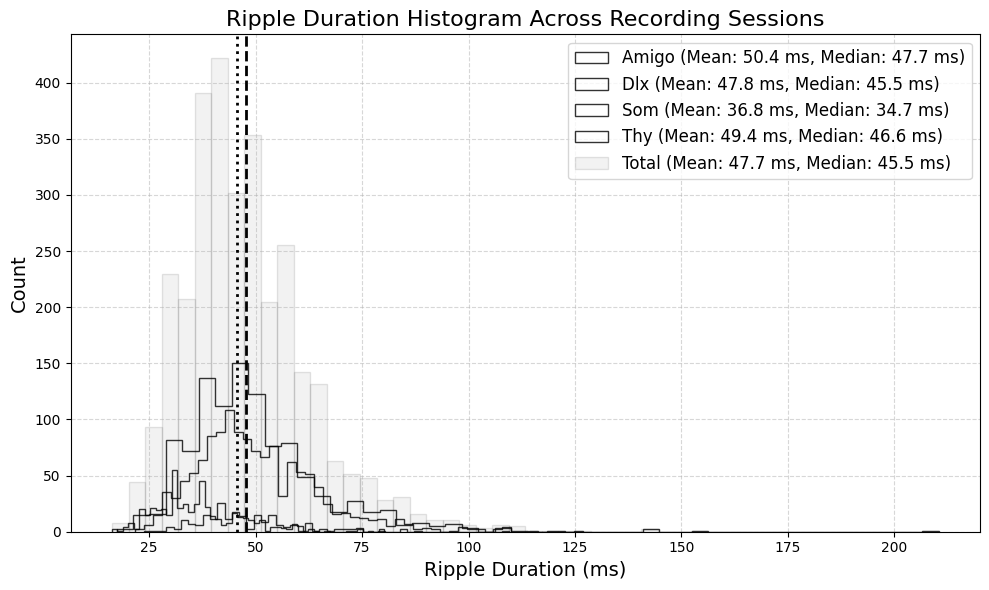

In [9]:
plot_multi_ripple_histograms(ripples, fs=30000, bins=50, alpha=0.8,colors=colors)

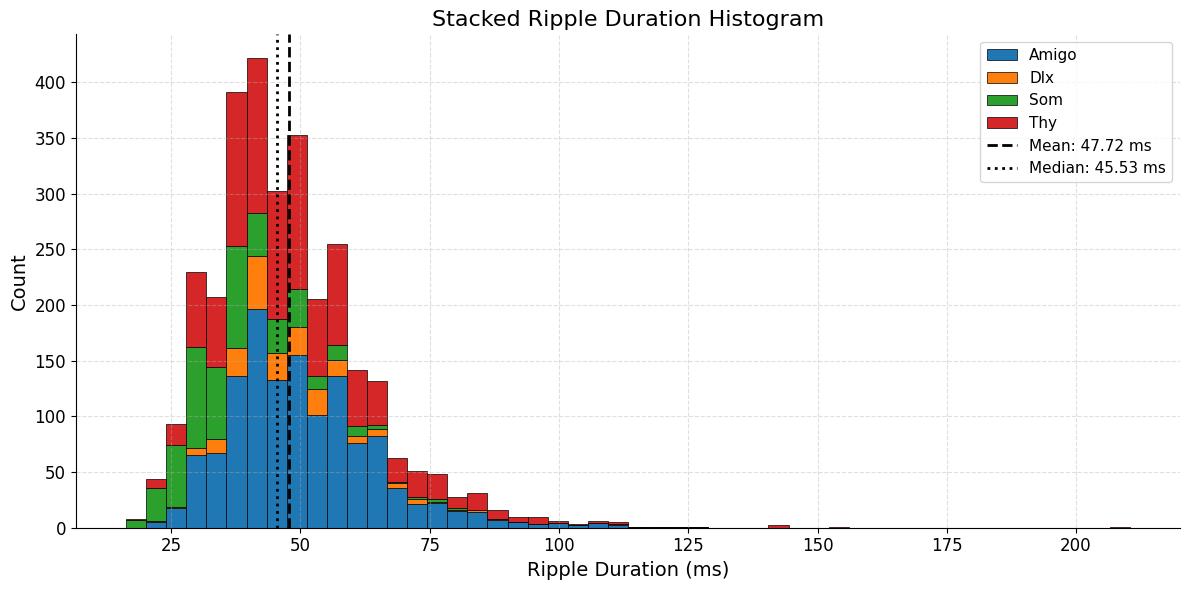

In [10]:
fig,ax=plot_stacked_histogram(ripples, fs=30000, bins=50, colors=colors)
fig_path=os.path.join(os.getcwd(),"pngs", "ripples_stacked_histogram.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')

In [11]:
def plot_single_ripple_histogram(ripples_list, fs, bins=50, alpha=0.6,color="blue"):
    """
    Plot ripple duration histograms for multiple datasets, each with a unique color.

    Parameters:
    - ripples_list: List of arrays (each [N x 2]) containing ripple start/end samples
    - fs: Sampling frequency in Hz
    - bins: Number of histogram bins
    - alpha: Transparency for histogram bars
    """

    assert len(ripples_list) == 4, "This function expects exactly 4 datasets."

    # colors = ['blue', 'green', 'orange', 'red']
    # labels = ['Amigo', 'Dlx', 'Som', 'Thy']
    all_ripples = np.concatenate(ripples_list, axis=0)
    plt.figure(figsize=(10, 6))

    durations_ms = (all_ripples[:, 1] - all_ripples[:, 0]) / fs * 1000  # Convert to ms    
    mean_duration = np.mean(durations_ms)
    std_duration = np.std(durations_ms)
    median_dur = np.median(durations_ms)
    plt.hist(durations_ms, bins=bins, alpha=alpha, color=color, edgecolor='black')
    plt.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.2f} ± {std_duration:.2f}ms')
    plt.axvline(median_dur, color='black', linestyle=':', linewidth=2, label=f'Median: {median_dur:.2f} ms')

    plt.xlabel("Ripple Duration (ms)", fontsize=14)
    plt.ylabel("Ripple Count", fontsize=14)
    plt.title("Ripple Duration Histogram Across Recording Sessions", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

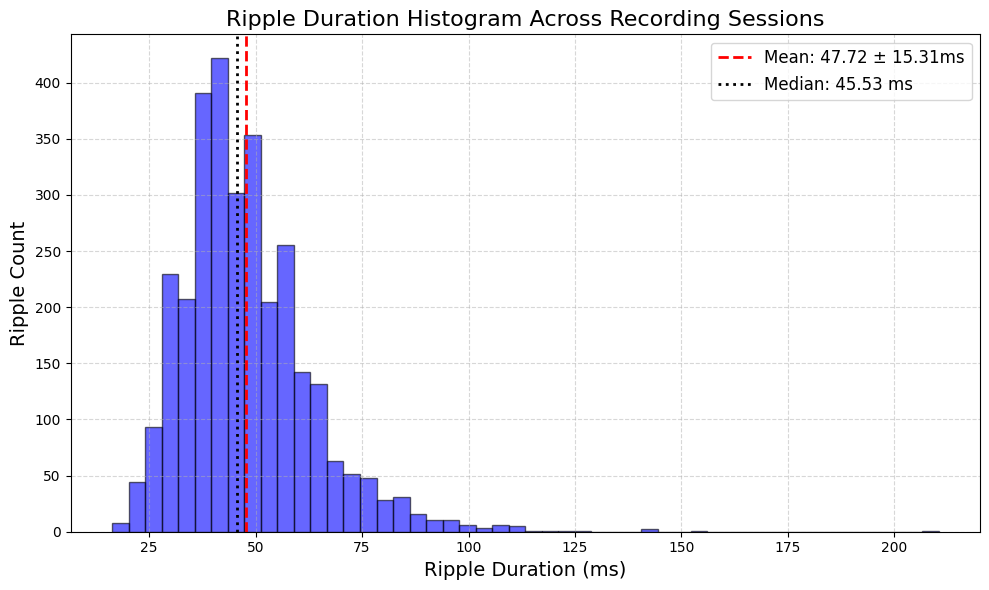

In [12]:
plot_single_ripple_histogram(ripples, 30000, bins=50, alpha=0.6,color="blue")

In [13]:
def difference_between_ripple_histograms(ripples_list, fs, bins=50, alpha=0.6,colors=colors):
    """
    Plot ripple duration histograms for multiple datasets, each with a unique color.

    Parameters:
    - ripples_list: List of arrays (each [N x 2]) containing ripple start/end samples
    - fs: Sampling frequency in Hz
    - bins: Number of histogram bins
    - alpha: Transparency for histogram bars
    """

    assert len(ripples_list) == 4, "This function expects exactly 4 datasets."

    # colors = ['blue', 'green', 'orange', 'red']
    labels = ['Amigo', 'Dlx', 'Som', 'Thy']
    
    plt.figure(figsize=(10, 6))
    diffs= []
    for idx, ripples in enumerate(ripples_list):
        difference_between=[]
              # print(ripples[:10])
        for i in range(len(ripples)-1):
            difference_between.append(ripples[i+1,0]-ripples[i,1])
        diffs_ms=  np.array(difference_between) / fs * 1000  # Convert to ms
        diffs.extend(diffs_ms)
        mean_dur = np.mean(diffs_ms)
        median_dur = np.median(diffs_ms)
        plt.hist(diffs_ms, bins=bins,histtype='step', alpha=alpha, color=colors[idx], label=f'{labels[idx]} (Mean: {mean_dur:.1f} ms, Median: {median_dur:.1f} ms)', edgecolor='black')
        # Mean and Median lines
        # plt.axvline(mean_dur, color=colors[idx], linestyle='--', linewidth=1)
        # plt.axvline(median_dur, color=colors[idx], linestyle=':', linewidth=1)

    mean_dur = np.mean(diffs)
    median_dur = np.median(diffs)
    plt.hist(diffs, bins=bins, alpha=0.1, color="grey", label=f'Total (Mean: {mean_dur:.1f} ms, Median: {median_dur:.1f} ms)', edgecolor='black')
    plt.axvline(mean_dur, color='black', linestyle='--', linewidth=2, )
    plt.axvline(median_dur, color='black', linestyle=':', linewidth=2,)

    plt.xlabel("Ripple Duration (ms)", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Ripple Duration Histogram Across Recording Sessions", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_stacked_difference_histogram(ripples_list, fs, bins=50, colors=None):
    """
    Plot a stacked histogram of the time differences between ripples (IRIs) across multiple datasets.
    
    Parameters:
    - ripples_list: List of arrays (each [N x 2]) containing ripple start/end samples
    - fs: Sampling frequency in Hz
    - bins: Number of histogram bins
    - colors: Optional list of colors (one per dataset)
    """
    assert len(ripples_list) == 4, "This function expects exactly 4 datasets."

    if colors is None:
        colors = ['royalblue', 'seagreen', 'darkorange', 'crimson']

    labels = ['Amigo', 'Dlx', 'Som', 'Thy']

    # Compute inter-ripple intervals (IRIs) for each dataset
    differences_list = []
    for ripples in ripples_list:
        ir_intervals = np.diff(ripples[:, 0]) - (ripples[:-1, 1] - ripples[:-1, 0])
        ir_intervals_ms = ir_intervals / fs * 1000
        differences_list.append(ir_intervals_ms)

    # Plot stacked histogram
    plt.figure(figsize=(12, 6))
    plt.hist(
        differences_list, bins=bins, stacked=True,
        color=colors[:len(ripples_list)], label=labels, edgecolor='black'
    )

    # Global stats
    all_differences = np.concatenate(differences_list, axis=0)
    mean_diff = np.mean(all_differences)
    median_diff = np.median(all_differences)

    plt.axvline(mean_diff, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_diff:.2f} ms')
    plt.axvline(median_diff, color='black', linestyle=':', linewidth=2, label=f'Median: {median_diff:.2f} ms')

    plt.xlabel("Inter-Ripple Interval (ms)", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Stacked Histogram of Inter-Ripple Intervals", fontsize=16)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


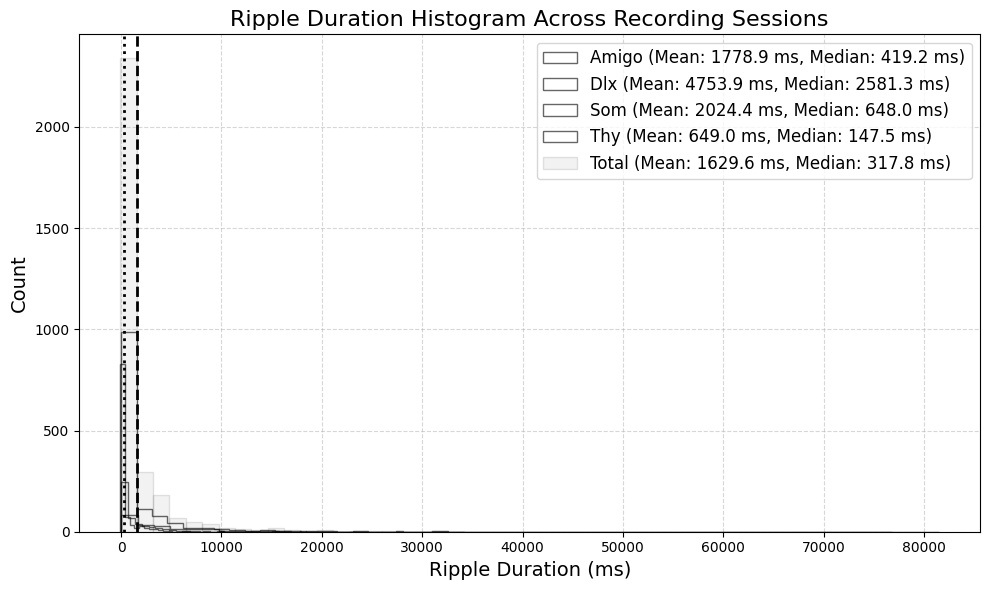

In [14]:
difference_between_ripple_histograms(ripples, fs=30000, bins=50, alpha=0.6,colors=colors)

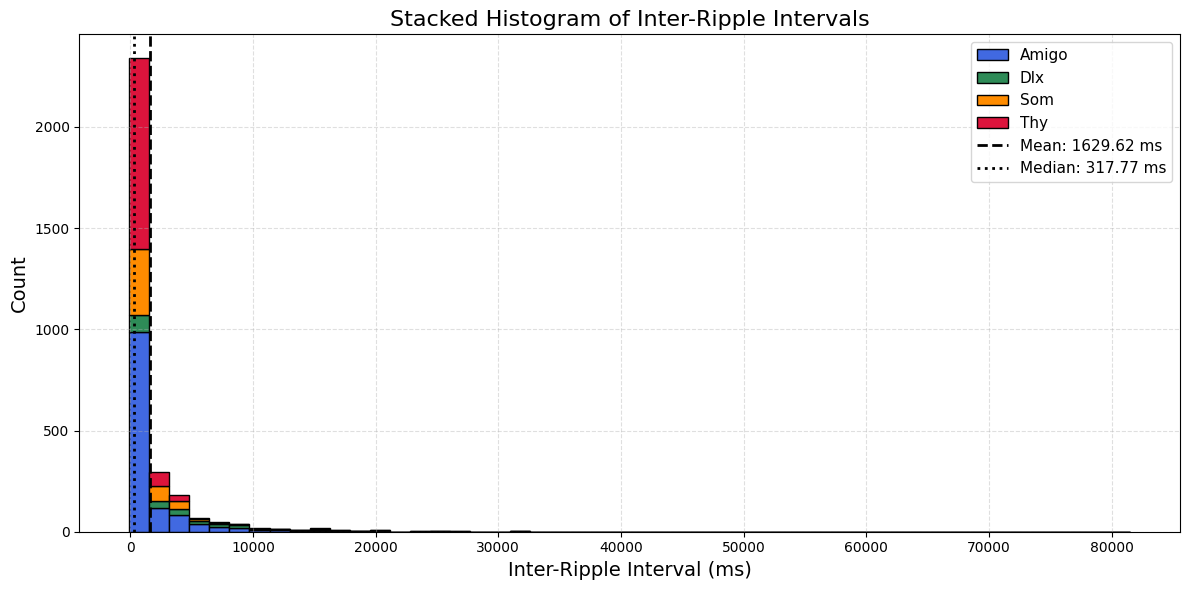

In [15]:
plot_stacked_difference_histogram(ripples, 30000, bins=50, colors=None)

In [16]:
def plot_single_ripple_difference_histogram(ripples_list, fs, bins=50, alpha=0.6, color="blue"):
    """
    Plot a histogram of inter-ripple intervals (differences between consecutive ripples)
    across all datasets combined.

    Parameters:
    - ripples_list: List of arrays (each [N x 2]) containing ripple start/end samples
    - fs: Sampling frequency in Hz
    - bins: Number of histogram bins
    - alpha: Transparency for histogram bars
    """
    assert len(ripples_list) == 4, "This function expects exactly 4 datasets."

    all_differences = []

    for ripples in ripples_list:
        # Difference between next start and current end: t_start[i+1] - t_end[i]
        ir_intervals = ripples[1:, 0] - ripples[:-1, 1]
        ir_intervals_ms = ir_intervals / fs * 1000  # Convert to ms
        all_differences.extend(ir_intervals_ms)

    all_differences = np.array(all_differences)
    mean_diff = np.mean(all_differences)
    std_diff = np.std(all_differences)
    median_diff = np.median(all_differences)

    plt.figure(figsize=(10, 6))
    plt.hist(all_differences, bins=bins, range=[0,10000],alpha=alpha, color=color, edgecolor='black')
    plt.axvline(mean_diff, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_diff:.2f} ± {std_diff:.2f} ms')
    plt.axvline(median_diff, color='black', linestyle=':', linewidth=2, label=f'Median: {median_diff:.2f} ms')

    plt.xlabel("Inter-Ripple Interval (ms)", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Inter-Ripple Interval Histogram Across Sessions", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


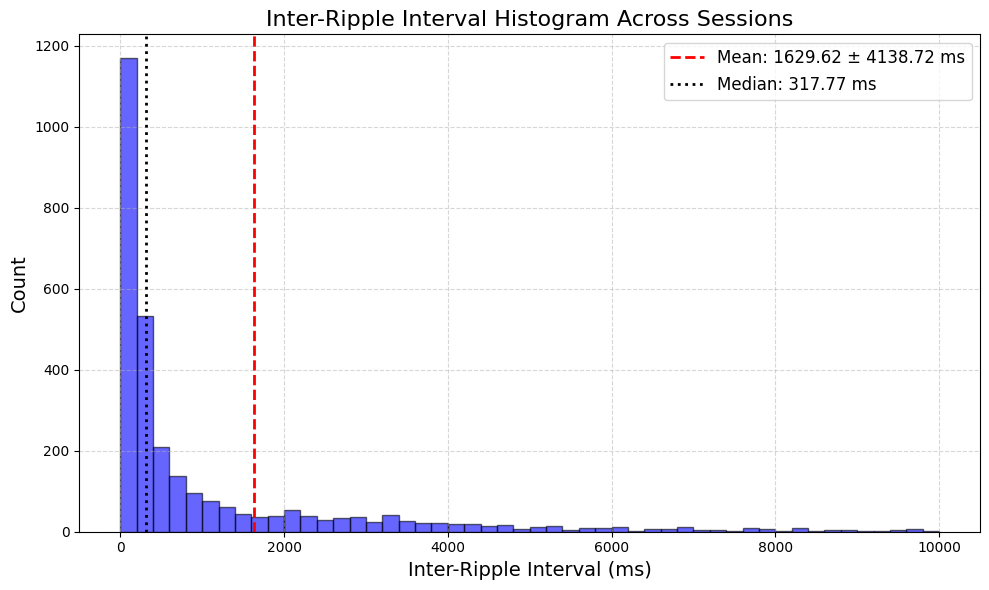

In [17]:
plot_single_ripple_difference_histogram(ripples, 30000, bins=50, alpha=0.6, color="blue")